# Cohort Data Creation

In [1]:
import pandas as pd
from LabData.DataLoaders.GutMBLoader import GutMBLoader
from LabData.DataLoaders.SubjectLoader import SubjectLoader
from LabData.DataLoaders.DietLoggingLoader import DietLoggingLoader
from LabData.DataLoaders.DietaryInterventionLoader import DietaryInterventionLoader
from LabData.DataLoaders.LifeStyleLoader import LifeStyleLoader
from LabData.DataLoaders.BodyMeasuresLoader import BodyMeasuresLoader
from LabData.DataAnalyses.TenK_Trajectories.utils import get_diet_logging_around_stage
import numpy as np
import pickle
from sklearn.preprocessing import StandardScaler


In [2]:
home_path = '/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/'
SPECIES = 'segal_species' # 'segal_species' or 'mpa_species'
species = 'segal_species'

# Study configuration
study_ids = ["PNP3"]  # [15] for Australian cohort, ['PNP3'] for PNP3
# Map study_ids to study name for file naming
study_name_map = {15: 'AU15', 'PNP3': 'PNP3'}
study_name = study_name_map.get(study_ids[0] if isinstance(study_ids[0], int) else study_ids[0], f'study_{study_ids[0]}')

min_col_present_frac = 0.05

In [3]:
diet_mb_10k = pd.read_pickle(home_path + f"data/{SPECIES}/diet_mb.pkl")
with open(home_path + f'data/{SPECIES}/my_lists.pkl', 'rb') as file:
    loaded_lists = pickle.load(file)
base_features_10k, all_features_10k, targets_10k = loaded_lists
with open(home_path + f'data/{SPECIES}/scaler.pkl', 'rb') as scaler_file:
        scaler_10k = pickle.load(scaler_file)
diet_mb_10k

,Acorn squash,Alfalfa sprouts,Almond Beverage,Almond flour,Almond spread,Almonds,Amba,Apple,Apple Cake,Apple Vinegar,...,Irritable Bowel Syndrome (IBS),Peptic Ulcer Disease,Gallstone disease,Asthma,Atopic dermatitis,Psoriasis,Allergy,Depression,Anxiety,Hypothyroidism
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
10K_1000942861,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.016416,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
10K_1001201093,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.013895,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10K_1002254441,0.0,0.0,0.0,0.0,0.0,0.081238,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10K_1003113258,0.0,0.0,0.0,0.0,0.0,0.002048,0.0,0.008929,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10K_1007330152,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10K_9996884777,0.0,0.0,0.0,0.0,0.0,0.002401,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10K_9998420917,0.0,0.0,0.0,0.0,0.0,0.019995,0.0,0.018783,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10K_9998635752,0.0,0.0,0.0,0.0,0.0,0.001607,0.0,0.011305,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
def explore_columns(df):
    for column in df.columns:
        print(column)
        print(df[column].value_counts())

# study_ids is defined in cell 2
subjects_dl = SubjectLoader()
subjects_data = subjects_dl.get_data(groupby_reg='first', study_ids=study_ids)
subjects_df = subjects_data.df
print(subjects_df)

                                      StudyTypeID  city country  gender  \
RegistrationCode Date                                                     
111527           2017-10-05 09:04:27          3.0  None      IL     0.0   
117111           2018-02-13 22:55:37          3.0  None      IL     1.0   
126092           2018-07-08 12:17:18          3.0  None      IL     0.0   
12752            2018-07-11 18:27:38          3.0  None      IL     1.0   
128811           2017-10-22 09:03:50          3.0  None      IL     1.0   
...                                           ...   ...     ...     ...   
988899           2017-09-12 18:55:41          3.0  None      IL     1.0   
991569           2017-10-23 15:47:35          3.0  None      IL     1.0   
992638           2017-05-09 15:01:09          3.0  None      IL     1.0   
997427           2018-12-16 14:32:00          3.0  None      IL     0.0   
997735           2018-11-10 20:19:55          3.0  None      IL     0.0   

                        

## Load Microbiome Data

In [5]:
gut_bacteria = GutMBLoader().get_data(SPECIES, subjects_df=subjects_df, study_ids=study_ids,
                                # groupby_reg='first', 
                                genotek_vals=[1], min_col_val=1e-4, take_log=True)
gut_bacteria_df = gut_bacteria.df.dropna(axis=1, how='all')
gut_bacteria_df.columns = gut_bacteria_df.columns.str.replace('s__', '')
# with open(home_path + f'data/{species}/my_lists.pkl', 'rb') as file:
#         loaded_lists = pickle.load(file)
# base_features, all_diet_features, targets = loaded_lists
gut_bacteria_df = gut_bacteria_df[targets_10k]



gut_bacteria_df.head(3)

species,fBin__100|gBin__473|sBin__693,fBin__100|gBin__473|sBin__694,fBin__100|gBin__474|sBin__695,fBin__100|gBin__477|sBin__698,fBin__100|gBin__481|sBin__704,fBin__100|gBin__481|sBin__705,fBin__100|gBin__481|sBin__706,fBin__100|gBin__483|sBin__709,fBin__102|gBin__490|sBin__720,fBin__102|gBin__490|sBin__721,...,fBin__86|gBin__428|sBin__630,fBin__86|gBin__429|sBin__631,fBin__88|gBin__434|sBin__637,fBin__94|gBin__448|sBin__654,fBin__94|gBin__449|sBin__656,fBin__95|gBin__450|sBin__659,fBin__96|gBin__457|sBin__669,fBin__97|gBin__462|sBin__676,fBin__97|gBin__462|sBin__678,fBin__99|gBin__469|sBin__687
SampleName,,,,,,,,,,,,,,,,,,,,,
111527_FD2548,-4.0,-2.086345,-4.000000,-2.352646,-4.0,-4.0,-4.0,-4.000000,-4.0,-2.363585,...,-4.0,-2.508425,-4.0,-4.0,-4.0,-4.000000,-2.316969,-4.0,-4.0,-4.0
111527_FD3121,-4.0,-2.170342,-4.000000,-2.195323,-4.0,-4.0,-4.0,-4.000000,-4.0,-2.923262,...,-4.0,-2.402360,-4.0,-4.0,-4.0,-4.000000,-2.509287,-4.0,-4.0,-4.0
117111_FD2737,-4.0,-4.000000,-1.455644,-2.461381,-4.0,-4.0,-4.0,-2.474627,-4.0,-4.000000,...,-4.0,-4.000000,-4.0,-4.0,-4.0,-2.778813,-4.000000,-4.0,-4.0,-4.0


In [6]:
gut_bacteria_df.shape

(434, 724)

In [7]:
gut_bacteria_df

species,fBin__100|gBin__473|sBin__693,fBin__100|gBin__473|sBin__694,fBin__100|gBin__474|sBin__695,fBin__100|gBin__477|sBin__698,fBin__100|gBin__481|sBin__704,fBin__100|gBin__481|sBin__705,fBin__100|gBin__481|sBin__706,fBin__100|gBin__483|sBin__709,fBin__102|gBin__490|sBin__720,fBin__102|gBin__490|sBin__721,...,fBin__86|gBin__428|sBin__630,fBin__86|gBin__429|sBin__631,fBin__88|gBin__434|sBin__637,fBin__94|gBin__448|sBin__654,fBin__94|gBin__449|sBin__656,fBin__95|gBin__450|sBin__659,fBin__96|gBin__457|sBin__669,fBin__97|gBin__462|sBin__676,fBin__97|gBin__462|sBin__678,fBin__99|gBin__469|sBin__687
SampleName,,,,,,,,,,,,,,,,,,,,,
111527_FD2548,-4.0,-2.086345,-4.000000,-2.352646,-4.0,-4.000000,-4.000000,-4.000000,-4.0,-2.363585,...,-4.0,-2.508425,-4.000000,-4.000000,-4.0,-4.000000,-2.316969,-4.0,-4.000000,-4.000000
111527_FD3121,-4.0,-2.170342,-4.000000,-2.195323,-4.0,-4.000000,-4.000000,-4.000000,-4.0,-2.923262,...,-4.0,-2.402360,-4.000000,-4.000000,-4.0,-4.000000,-2.509287,-4.0,-4.000000,-4.000000
117111_FD2737,-4.0,-4.000000,-1.455644,-2.461381,-4.0,-4.000000,-4.000000,-2.474627,-4.0,-4.000000,...,-4.0,-4.000000,-4.000000,-4.000000,-4.0,-2.778813,-4.000000,-4.0,-4.000000,-4.000000
126092_FD3052,-4.0,-4.000000,-4.000000,-4.000000,-4.0,-2.507812,-2.598919,-4.000000,-4.0,-3.466638,...,-4.0,-3.212163,-4.000000,-4.000000,-4.0,-4.000000,-3.291187,-4.0,-4.000000,-2.574834
12752_FD3045,-4.0,-4.000000,-2.970293,-3.342791,-4.0,-4.000000,-2.290960,-3.713482,-4.0,-4.000000,...,-4.0,-4.000000,-4.000000,-3.964632,-4.0,-4.000000,-4.000000,-4.0,-4.000000,-3.328104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991569_FD2535,-4.0,-4.000000,-4.000000,-3.565695,-4.0,-4.000000,-2.796071,-3.251770,-4.0,-4.000000,...,-4.0,-4.000000,-4.000000,-3.253435,-4.0,-2.424118,-4.000000,-4.0,-3.947564,-4.000000
992638_FD2066,-4.0,-4.000000,-4.000000,-4.000000,-4.0,-4.000000,-4.000000,-2.154990,-4.0,-4.000000,...,-4.0,-4.000000,-4.000000,-3.685354,-4.0,-4.000000,-4.000000,-4.0,-3.904635,-4.000000
992638_FD3079,-4.0,-4.000000,-4.000000,-4.000000,-4.0,-4.000000,-4.000000,-2.315675,-4.0,-4.000000,...,-4.0,-4.000000,-4.000000,-4.000000,-4.0,-4.000000,-4.000000,-4.0,-4.000000,-4.000000


In [8]:
gut_bacteria.df_metadata

,RegistrationCode,GenesetMapCount,HGMappedRC,MPAMapCount,Nextera,PE,PostBBDRC,PostHGFRC,PostQCRC,PostTrimRC,...,StudyTypeID6,StudyTypeID9,age,city,StudyTypeID5,country,us_state,StudyTypeID8,StudyTypeID4,gender
SampleName,,,,,,,,,,,,,,,,,,,,,
111527_FD2548,111527,8089026.0,6564.0,370881.0,True,False,NaN,24694342.0,24700906.0,25488383.0,...,NaN,NaN,46.0,None,NaN,IL,None,NaN,NaN,0.0
111527_FD3121,111527,8335905.0,166062.0,319110.0,True,False,NaN,17086609.0,17252671.0,17326455.0,...,NaN,NaN,47.0,None,NaN,IL,None,NaN,NaN,0.0
117111_FD2737,117111,8009293.0,23379.0,253380.0,True,False,NaN,16574770.0,16598149.0,16847094.0,...,NaN,NaN,47.0,None,NaN,IL,None,NaN,NaN,1.0
126092_FD3052,126092,7809523.0,17579.0,106637.0,True,False,NaN,15970046.0,15987625.0,16083149.0,...,NaN,NaN,56.0,None,NaN,IL,None,NaN,NaN,0.0
12752_FD3045,12752,7414672.0,5340.0,58295.0,True,False,NaN,13934250.0,13939590.0,14252384.0,...,NaN,NaN,56.0,None,NaN,IL,None,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991569_FD2535,991569,7253120.0,19360.0,80406.0,True,False,NaN,17458787.0,17478147.0,17853575.0,...,NaN,NaN,51.0,None,NaN,IL,None,NaN,NaN,1.0
992638_FD2066,992638,NaN,1318.0,NaN,True,False,NaN,9747730.0,9749048.0,9994279.0,...,NaN,NaN,53.0,None,NaN,IL,None,NaN,NaN,1.0
992638_FD3079,992638,7765976.0,1809.0,145193.0,True,False,NaN,13847924.0,13849733.0,13881280.0,...,NaN,NaN,54.0,None,NaN,IL,None,NaN,NaN,1.0


In [9]:
gut_bacteria_df = gut_bacteria_df.join(gut_bacteria.df_metadata[['RegistrationCode', 'Date']]).set_index(['RegistrationCode', 'Date'])
gut_bacteria_df.tail(20)

fBin__100|gBin__473|sBin__693  \
RegistrationCode Date                                                 
948714           2017-06-13 11:30:57                      -4.000000   
                 2018-01-04 08:30:06                      -4.000000   
953534           2018-07-09 14:11:17                      -4.000000   
954295           2018-01-29 06:00:46                      -4.000000   
                 2018-09-04 12:19:16                      -4.000000   
954766           2018-10-08 07:45:11                      -4.000000   
956564           2018-07-09 14:08:59                      -4.000000   
963150           2018-10-11 15:04:59                      -4.000000   
967551           2018-08-22 10:20:01                      -4.000000   
970940           2019-02-03 13:48:40                      -4.000000   
972181           2018-12-28 00:30:29                      -4.000000   
979162           2018-04-23 06:30:09                      -4.000000   
981727           2018-10-11 14:57:37                      -4.000000   
988899           2017-09-24 13:25:52                      -3.649303   
                 2018-05-15 10:32:11                      -3.900757   
991569           2017-11-05 10:32:59                      -4.000000   
992638           2017-06-13 11:27:11                      -4.000000   
                 2018-01-03 06:00:24                      -4.000000   
997427           2019-01-01 16:00:38                      -4.000000   
997735           2018-12-30 12:42:55                      -4.000000   

                                      fBin__100|gBin__473|sBin__694  \
RegistrationCode Date                                                 
948714           2017-06-13 11:30:57                      -3.912283   
                 2018-01-04 08:30:06                      -3.635795   
953534           2018-07-09 14:11:17                      -4.000000   
954295           2018-01-29 06:00:46                      -4.000000   
                 2018-09-04 12:19:16                      -4.000000   
954766           2018-10-08 07:45:11                      -4.000000   
956564           2018-07-09 14:08:59                      -4.000000   
963150           2018-10-11 15:04:59                      -4.000000   
967551           2018-08-22 10:20:01                      -4.000000   
970940           2019-02-03 13:48:40                      -4.000000   
972181           2018-12-28 00:30:29                      -4.000000   
979162           2018-04-23 06:30:09                      -4.000000   
981727           2018-10-11 14:57:37                      -4.000000   
988899           2017-09-24 13:25:52                      -4.000000   
                 2018-05-15 10:32:11                      -4.000000   
991569           2017-11-05 10:32:59                      -4.000000   
992638           2017-06-13 11:27:11                      -4.000000   
                 2018-01-03 06:00:24                      -4.000000   
997427           2019-01-01 16:00:38                      -4.000000   
997735           2018-12-30 12:42:55                      -4.000000   

                                      fBin__100|gBin__474|sBin__695  \
RegistrationCode Date                                                 
948714           2017-06-13 11:30:57                      -4.000000   
                 2018-01-04 08:30:06                      -4.000000   
953534           2018-07-09 14:11:17                      -4.000000   
954295           2018-01-29 06:00:46                      -4.000000   
                 2018-09-04 12:19:16                      -4.000000   
954766           2018-10-08 07:45:11                      -4.000000   
956564           2018-07-09 14:08:59                      -4.000000   
963150           2018-10-11 15:04:59                      -4.000000   
967551           2018-08-22 10:20:01                      -4.000000   
970940           2019-02-03 13:48:40                      -4.000000   
972181           2018-12-28 00:30:29                      -4

In [10]:
# Filter people that don't have two tests
gut_bacteria_df = gut_bacteria_df.groupby(level=0).filter(lambda x: x.index.get_level_values('Date').nunique() == 2).sort_index()

gut_bacteria_df

fBin__100|gBin__473|sBin__693  \
RegistrationCode Date                                                 
111527           2017-11-06 12:06:15                           -4.0   
                 2018-06-17 11:55:37                           -4.0   
117111           2018-04-29 13:01:29                           -4.0   
                 2018-11-27 15:47:10                           -4.0   
126092           2018-11-19 11:32:06                           -4.0   
...                                                             ...   
992638           2018-01-03 06:00:24                           -4.0   
997427           2019-01-01 16:00:38                           -4.0   
                 2019-09-07 10:15:59                           -4.0   
997735           2018-12-30 12:42:55                           -4.0   
                 2019-07-19 15:11:21                           -4.0   

                                      fBin__100|gBin__473|sBin__694  \
RegistrationCode Date                                                 
111527           2017-11-06 12:06:15                      -2.086345   
                 2018-06-17 11:55:37                      -2.170342   
117111           2018-04-29 13:01:29                      -4.000000   
                 2018-11-27 15:47:10                      -4.000000   
126092           2018-11-19 11:32:06                      -4.000000   
...                                                             ...   
992638           2018-01-03 06:00:24                      -4.000000   
997427           2019-01-01 16:00:38                      -4.000000   
                 2019-09-07 10:15:59                      -4.000000   
997735           2018-12-30 12:42:55                      -4.000000   
                 2019-07-19 15:11:21                      -4.000000   

                                      fBin__100|gBin__474|sBin__695  \
RegistrationCode Date                                                 
111527           2017-11-06 12:06:15                      -4.000000   
                 2018-06-17 11:55:37                      -4.000000   
117111           2018-04-29 13:01:29                      -1.455644   
                 2018-11-27 15:47:10                      -1.868739   
126092           2018-11-19 11:32:06                      -4.000000   
...                                                             ...   
992638           2018-01-03 06:00:24                      -4.000000   
997427           2019-01-01 16:00:38                      -4.000000   
                 2019-09-07 10:15:59                      -4.000000   
997735           2018-12-30 12:42:55                      -2.132467   
                 2019-07-19 15:11:21                      -2.503448   

                                      fBin__100|gBin__477|sBin__698  \
RegistrationCode Date                                                 
111527           2017-11-06 12:06:15                      -2.352646   
                 2018-06-17 11:55:37                      -2.195323   
117111           2018-04-29 13:01:29                      -2.461381   
                 2018-11-27 15:47:10                      -3.022088   
126092           2018-11-19 11:32:06                      -4.000000   
...                                                             ...   
992638           2018-01-03 06:00:24                      -4.000000   
997427           2019-01-01 16:00:38                      -4.000000   
                 2019-09-07 10:15:59                      -4.000000   
997735           2018-12-30 12:42:55                      -3.331094   
                 2019-07-19 15:11:21                      -4.000000   

                                      fBin__100|gBin__481|sBin__704  \
RegistrationCode Date                                                 
111527           2017-11-06 12:06:15                           -4.0   
                 2018-06-17 11:55:37                           -4.0   
117111           2018-04-29 13:01:29                      

In [11]:
# Normalize by row.

# Step 1: Convert to normal scale
gut_bacteria_df_normal = 10 ** gut_bacteria_df

# Step 2: Mask of values that are NOT 0.0001
mask = gut_bacteria_df_normal != 0.0001

# Step 3: Row-wise sum of the non-0.0001 values
non_floor_sum = gut_bacteria_df_normal.where(mask).sum(axis=1)

# Step 4: Normalize ONLY the non-0.0001 values, keep 0.0001 unchanged
gut_bacteria_df_normal = gut_bacteria_df_normal.where(~mask, gut_bacteria_df_normal.div(non_floor_sum, axis=0))

# Step 5: Convert back to log10
gut_bacteria_df_log = np.log10(gut_bacteria_df_normal)
gut_bacteria_df = gut_bacteria_df_log
gut_bacteria_df

fBin__100|gBin__473|sBin__693  \
RegistrationCode Date                                                 
111527           2017-11-06 12:06:15                           -4.0   
                 2018-06-17 11:55:37                           -4.0   
117111           2018-04-29 13:01:29                           -4.0   
                 2018-11-27 15:47:10                           -4.0   
126092           2018-11-19 11:32:06                           -4.0   
...                                                             ...   
992638           2018-01-03 06:00:24                           -4.0   
997427           2019-01-01 16:00:38                           -4.0   
                 2019-09-07 10:15:59                           -4.0   
997735           2018-12-30 12:42:55                           -4.0   
                 2019-07-19 15:11:21                           -4.0   

                                      fBin__100|gBin__473|sBin__694  \
RegistrationCode Date                                                 
111527           2017-11-06 12:06:15                      -2.086026   
                 2018-06-17 11:55:37                      -2.169741   
117111           2018-04-29 13:01:29                      -4.000000   
                 2018-11-27 15:47:10                      -4.000000   
126092           2018-11-19 11:32:06                      -4.000000   
...                                                             ...   
992638           2018-01-03 06:00:24                      -4.000000   
997427           2019-01-01 16:00:38                      -4.000000   
                 2019-09-07 10:15:59                      -4.000000   
997735           2018-12-30 12:42:55                      -4.000000   
                 2019-07-19 15:11:21                      -4.000000   

                                      fBin__100|gBin__474|sBin__695  \
RegistrationCode Date                                                 
111527           2017-11-06 12:06:15                      -4.000000   
                 2018-06-17 11:55:37                      -4.000000   
117111           2018-04-29 13:01:29                      -1.448965   
                 2018-11-27 15:47:10                      -1.866822   
126092           2018-11-19 11:32:06                      -4.000000   
...                                                             ...   
992638           2018-01-03 06:00:24                      -4.000000   
997427           2019-01-01 16:00:38                      -4.000000   
                 2019-09-07 10:15:59                      -4.000000   
997735           2018-12-30 12:42:55                      -2.128541   
                 2019-07-19 15:11:21                      -2.496576   

                                      fBin__100|gBin__477|sBin__698  \
RegistrationCode Date                                                 
111527           2017-11-06 12:06:15                      -2.352327   
                 2018-06-17 11:55:37                      -2.194721   
117111           2018-04-29 13:01:29                      -2.454702   
                 2018-11-27 15:47:10                      -3.020171   
126092           2018-11-19 11:32:06                      -4.000000   
...                                                             ...   
992638           2018-01-03 06:00:24                      -4.000000   
997427           2019-01-01 16:00:38                      -4.000000   
                 2019-09-07 10:15:59                      -4.000000   
997735           2018-12-30 12:42:55                      -3.327168   
                 2019-07-19 15:11:21                      -4.000000   

                                      fBin__100|gBin__481|sBin__704  \
RegistrationCode Date                                                 
111527           2017-11-06 12:06:15                           -4.0   
                 2018-06-17 11:55:37                           -4.0   
117111           2018-04-29 13:01:29                      

In [12]:
row_number = gut_bacteria_df.groupby(level=0).cumcount()

# Split the DataFrame into baseline_mb and intervention_mb based on the row number
baseline_mb = gut_bacteria_df[row_number == 0]
intervention_mb = gut_bacteria_df[row_number == 1]

baseline_mb = baseline_mb.reset_index(level=[1], drop=True)
intervention_mb = intervention_mb.reset_index(level=[1], drop=True)

In [13]:
gut_bacteria_df_col = gut_bacteria.df_columns_metadata
# View 5 most common bacteria
gut_bacteria_df_col[gut_bacteria_df_col['Unnamed: 0'].isin(["Rep_485", "Rep_609", "Rep_477", "Rep_449", "Rep_231"])]

,Unnamed: 0,kingdom,phylum,class,order,family,genus,species,sBin,gBin,...,sSGB,gSGB,fSGB,kingdom_new,phylum_new,class_new,order_new,family_new,genus_new,species_new
fBin__45|gBin__157|sBin__231,Rep_231,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Prevotella,Prevotella copri,231.0,157.0,...,1626,1238,579,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Prevotella,Prevotella copri_B
fBin__73|gBin__324|sBin__449,Rep_449,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Phocaeicola,Phocaeicola vulgatus,449.0,324.0,...,1814,1353,595,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Phocaeicola,Phocaeicola vulgatus
fBin__73|gBin__337|sBin__477,Rep_477,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,Bacteroides uniformis,477.0,337.0,...,1836,1366,595,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,Bacteroides uniformis
fBin__73|gBin__341|sBin__485,Rep_485,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Phocaeicola,unknown,485.0,341.0,...,1854,1371,595,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Phocaeicola,unknown
fBin__86|gBin__419|sBin__609,Rep_609,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Rikenellaceae,Alistipes,Alistipes putredinis,609.0,419.0,...,2318,1686,673,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Rikenellaceae,Alistipes,Alistipes putredinis


In [14]:
gut_bacteria_df_col.to_pickle(home_path + f"data/mb_names_{study_name.lower()}.pkl")

In [15]:
gut_bacteria_df_meta = gut_bacteria.df_metadata
print(gut_bacteria_df_meta.head())
# Check that there's only one mb test per person
gut_bacteria_df_meta.RegistrationCode.value_counts()

              RegistrationCode GenesetMapCount HGMappedRC MPAMapCount Nextera  \
SampleName                                                                      
111527_FD2548           111527       8089026.0     6564.0    370881.0    True   
111527_FD3121           111527       8335905.0   166062.0    319110.0    True   
117111_FD2737           117111       8009293.0    23379.0    253380.0    True   
126092_FD3052           126092       7809523.0    17579.0    106637.0    True   
12752_FD3045             12752       7414672.0     5340.0     58295.0    True   

                  PE PostBBDRC   PostHGFRC    PostQCRC  PostTrimRC  ...  \
SampleName                                                          ...   
111527_FD2548  False       NaN  24694342.0  24700906.0  25488383.0  ...   
111527_FD3121  False       NaN  17086609.0  17252671.0  17326455.0  ...   
117111_FD2737  False       NaN  16574770.0  16598149.0  16847094.0  ...   
126092_FD3052  False       NaN  15970046.0  15987625.0  1

831208    3
111527    2
243235    2
287239    2
299260    2
         ..
690622    1
69618     1
722655    1
745073    1
548470    1
Name: RegistrationCode, Length: 241, dtype: int64

### Alpha diversity targets

In [16]:
# Richness
def richness(row):
    filtered = row[row > -4]
    return len(filtered)

baseline_mb['Richness'] = baseline_mb.apply(richness, axis=1)
intervention_mb['Richness'] = intervention_mb.apply(richness, axis=1)
baseline_mb

,fBin__100|gBin__473|sBin__693,fBin__100|gBin__473|sBin__694,fBin__100|gBin__474|sBin__695,fBin__100|gBin__477|sBin__698,fBin__100|gBin__481|sBin__704,fBin__100|gBin__481|sBin__705,fBin__100|gBin__481|sBin__706,fBin__100|gBin__483|sBin__709,fBin__102|gBin__490|sBin__720,fBin__102|gBin__490|sBin__721,...,fBin__86|gBin__429|sBin__631,fBin__88|gBin__434|sBin__637,fBin__94|gBin__448|sBin__654,fBin__94|gBin__449|sBin__656,fBin__95|gBin__450|sBin__659,fBin__96|gBin__457|sBin__669,fBin__97|gBin__462|sBin__676,fBin__97|gBin__462|sBin__678,fBin__99|gBin__469|sBin__687,Richness
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
111527,-4.000000,-2.086026,-4.000000,-2.352327,-4.0,-4.000000,-4.000000,-4.000000,-4.0,-2.363266,...,-2.508106,-4.000000,-4.000000,-4.0,-4.000000,-2.316650,-4.0,-4.000000,-4.000000,110
117111,-4.000000,-4.000000,-1.448965,-2.454702,-4.0,-4.000000,-4.000000,-2.467948,-4.0,-4.000000,...,-4.000000,-4.000000,-4.000000,-4.0,-2.772134,-4.000000,-4.0,-4.000000,-4.000000,163
126092,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-2.315112,-2.406219,-4.000000,-4.0,-3.273938,...,-3.019464,-4.000000,-4.000000,-4.0,-4.000000,-3.098488,-4.0,-4.000000,-2.382134,184
12752,-4.000000,-4.000000,-2.641644,-3.014142,-4.0,-4.000000,-1.962311,-3.384833,-4.0,-4.000000,...,-4.000000,-4.000000,-3.635983,-4.0,-4.000000,-4.000000,-4.0,-4.000000,-2.999455,107
130279,-4.000000,-4.000000,-4.000000,-2.909901,-4.0,-4.000000,-4.000000,-2.436389,-4.0,-4.000000,...,-3.972362,-3.743862,-4.000000,-4.0,-4.000000,-4.000000,-4.0,-4.000000,-4.000000,159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
981727,-4.000000,-4.000000,-2.980255,-3.711814,-4.0,-4.000000,-4.000000,-3.479960,-4.0,-4.000000,...,-4.000000,-4.000000,-3.071785,-4.0,-2.884203,-4.000000,-4.0,-4.000000,-4.000000,260
988899,-3.625346,-4.000000,-4.000000,-2.183952,-4.0,-4.000000,-4.000000,-2.617710,-4.0,-4.000000,...,-2.772320,-4.000000,-3.090213,-4.0,-4.000000,-4.000000,-4.0,-4.000000,-4.000000,146
992638,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.000000,-4.000000,-2.030492,-4.0,-4.000000,...,-4.000000,-4.000000,-3.560856,-4.0,-4.000000,-4.000000,-4.0,-3.780138,-4.000000,167


In [17]:
# Shannon Diversity
def shannon(row):
    filtered = row[row > -4]
    filtered = filtered.drop("Richness")
    
    rel_abundance = 10 ** filtered
    ln_rel_abundance = np.log(rel_abundance.replace(0, 1))
    product = rel_abundance * ln_rel_abundance
    ans = -1 * product.sum()
    return round(float(ans), 2)

baseline_mb['Shannon_diversity'] = baseline_mb.apply(shannon, axis=1)
intervention_mb['Shannon_diversity'] = intervention_mb.apply(shannon, axis=1)
intervention_mb

,fBin__100|gBin__473|sBin__693,fBin__100|gBin__473|sBin__694,fBin__100|gBin__474|sBin__695,fBin__100|gBin__477|sBin__698,fBin__100|gBin__481|sBin__704,fBin__100|gBin__481|sBin__705,fBin__100|gBin__481|sBin__706,fBin__100|gBin__483|sBin__709,fBin__102|gBin__490|sBin__720,fBin__102|gBin__490|sBin__721,...,fBin__88|gBin__434|sBin__637,fBin__94|gBin__448|sBin__654,fBin__94|gBin__449|sBin__656,fBin__95|gBin__450|sBin__659,fBin__96|gBin__457|sBin__669,fBin__97|gBin__462|sBin__676,fBin__97|gBin__462|sBin__678,fBin__99|gBin__469|sBin__687,Richness,Shannon_diversity
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
111527,-4.000000,-2.169741,-4.000000,-2.194721,-4.000000,-4.000000,-4.000000,-4.000000,-4.000000,-2.922660,...,-4.000000,-4.000000,-4.000000,-4.000000,-2.508685,-4.0,-4.000000,-4.000000,149,3.46
117111,-4.000000,-4.000000,-1.866822,-3.020171,-4.000000,-4.000000,-4.000000,-3.216401,-3.931863,-2.850345,...,-4.000000,-4.000000,-3.327926,-2.345744,-4.000000,-4.0,-4.000000,-4.000000,217,3.93
126092,-3.601768,-4.000000,-4.000000,-4.000000,-3.065126,-2.009351,-2.120734,-4.000000,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-4.000000,-2.595642,-4.0,-4.000000,-2.013733,199,3.94
12752,-4.000000,-4.000000,-2.562619,-2.258574,-4.000000,-4.000000,-1.604241,-2.594847,-4.000000,-4.000000,...,-4.000000,-3.140830,-4.000000,-4.000000,-4.000000,-4.0,-4.000000,-2.458283,209,3.97
130279,-4.000000,-4.000000,-4.000000,-2.742665,-4.000000,-4.000000,-4.000000,-1.988424,-4.000000,-4.000000,...,-2.593218,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-3.760075,-4.000000,198,2.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
981727,-4.000000,-4.000000,-2.789824,-2.983543,-4.000000,-4.000000,-4.000000,-3.562991,-4.000000,-4.000000,...,-4.000000,-2.852334,-4.000000,-2.330696,-4.000000,-4.0,-4.000000,-4.000000,263,3.97
988899,-3.898066,-4.000000,-4.000000,-2.838314,-4.000000,-4.000000,-4.000000,-2.221572,-4.000000,-4.000000,...,-4.000000,-3.575834,-4.000000,-4.000000,-4.000000,-4.0,-4.000000,-4.000000,190,2.10
992638,-4.000000,-4.000000,-4.000000,-4.000000,-4.000000,-4.000000,-4.000000,-2.191233,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.000000,-4.000000,145,2.22


In [18]:

if species == 'mpa_species':
    path_to_tree = '/net/mraid20/export/genie/Bin/frcfrc/segata.k21.2023-01-31.tree'
elif species == 'segal_species':
    path_to_tree = '/net/mraid20/export/genie/Bin/frcfrc/segal.k21.2023-01-10.tree'
else:
    raise ValueError(f"Unknown SPECIES: {species}")

with open(path_to_tree, 'r') as f:
    print(f.read(100))

(((('Rep_1.fa.gz':0.09806286920996136,'Rep_2.fa.gz':0.09806286920996136):0.1939745655157457,('Rep_3.


In [19]:
import pandas as pd
from skbio import TreeNode

# 1. Load the tree (if not already loaded)
tree = TreeNode.read(path_to_tree)

# 2. Create the Mapping Dictionary
# The user specified: 
#   - Key (Source): First column of dataframe (values like "Rep_33")
#   - Value (Target): The index of the dataframe (values like "fBin__14|gBin__27|sBin__33")
# We create a dictionary: {'Rep_33': 'fBin__14|gBin__27|sBin__33', ...}
name_mapping = pd.Series(
    gut_bacteria_df_col.index.values,       # The Target (Index)
    index=gut_bacteria_df_col.iloc[:, 0]    # The Source (First Column)
).to_dict()

# 3. Rename the Tree Tips
count_renamed = 0
for tip in tree.tips():
    # The current tip name is like "Rep_33.fa.gz"
    # We strip ".fa.gz" to get "Rep_33" so we can look it up in the dictionary
    clean_name = tip.name.replace(".fa.gz", "")
    
    # Check if this Rep ID exists in our mapping
    if clean_name in name_mapping:
        # Update the tip name to the full species string
        tip.name = name_mapping[clean_name]
        count_renamed += 1

print(f"Successfully renamed {count_renamed} tips.")

# Optional: Verify a few tips to make sure it worked
print("First 5 new tip names:")
for tip in list(tree.tips())[:5]:
    print(tip.name)

# 4. Now you can calculate Faith's PD using the dataframe with species index
# Ensure your abundance table columns also match these new tree tip names!

Successfully renamed 3594 tips.
First 5 new tip names:
fBin__1|gBin__1|sBin__1
fBin__1|gBin__2|sBin__2
fBin__2|gBin__3|sBin__3
fBin__3|gBin__4|sBin__4
fBin__3|gBin__5|sBin__5


In [20]:
# Iterate over all nodes (tips and internal nodes)
for node in tree.traverse():
    # If branch length is missing (None), set it to 0.0
    if node.length is None:
        node.length = 0.0

print("Tree patched: All missing branch lengths set to 0.0.")

Tree patched: All missing branch lengths set to 0.0.


In [21]:
import pandas as pd
from skbio.diversity.alpha import faith_pd
import numpy as np

def get_faith_index(df, tree):
    """
    Calculates Faith's Phylogenetic Diversity.
    Fixes the 'Integer Truncation' bug by passing 1s instead of floats.
    """
    # 1. Drop metadata
    taxa_df = df.drop(columns=["Richness", "Shannon_diversity", "Faith_index"], errors='ignore')
    
    # 2. Alignment Check
    tree_tips = {tip.name for tip in tree.tips()}
    valid_cols = [c for c in taxa_df.columns if c in tree_tips]
    taxa_df = taxa_df[valid_cols]

    def calculate_row_pd(row):
        # 3. Filter for Presence
        # Keep species with log abundance > -4
        present_taxa = row[row > -4]
        
        if present_taxa.empty:
            return 0.0
        
        # 4. The Fix: Create a Fake Count Vector of Integers
        # We create a Series of 1s, indexed by the species names.
        # This tells faith_pd: "These species are definitely present."
        present_counts = pd.Series(1, index=present_taxa.index, dtype=int)
        
        try:
            return faith_pd(present_counts, present_taxa.index, tree)
        except ValueError:
            return float('nan')

    # Apply to every row
    return taxa_df.apply(calculate_row_pd, axis=1)

# Usage
baseline_mb['Faith_index'] = get_faith_index(baseline_mb, tree)
intervention_mb['Faith_index'] = get_faith_index(baseline_mb, tree)

# Check results (Should now be > 46.6)
print(baseline_mb[['Faith_index']].head())
print(intervention_mb[['Faith_index']].head())

                  Faith_index
RegistrationCode             
111527              18.406913
117111              23.952442
126092              27.321507
12752               17.454794
130279              21.982700
                  Faith_index
RegistrationCode             
111527              18.406913
117111              23.952442
126092              27.321507
12752               17.454794
130279              21.982700


Pearson Correlation: 0.98 (Should be > 0.8)
Pearson Correlation: 0.78 (Should be > 0.8)
Pearson Correlation: 0.78 (Should be > 0.8)


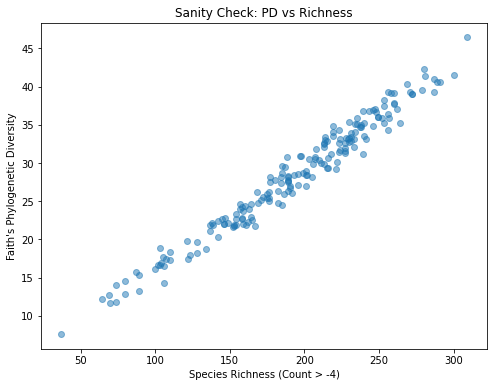

In [22]:
# Sanity check
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Calculate Simple Richness (Count of species > -4 log abundance)
# We drop the metadata columns first to ensure we only count bacteria

# 2. Plot
plt.figure(figsize=(8, 6))
plt.scatter(baseline_mb['Richness'], baseline_mb['Faith_index'], alpha=0.5)
plt.xlabel('Species Richness (Count > -4)')
plt.ylabel("Faith's Phylogenetic Diversity")
plt.title('Sanity Check: PD vs Richness')

# 3. Correlation Score
# corr, p_val = stats.spearmanr(gut_bacteria_df['Richness'], gut_bacteria_df['Faith_index'])
# print(f"Spearman Correlation: {corr:.2f} (Should be > 0.8)")
corr, p_val = stats.pearsonr(baseline_mb['Richness'], baseline_mb['Faith_index'])
print(f"Pearson Correlation: {corr:.2f} (Should be > 0.8)")
corr, p_val = stats.pearsonr(baseline_mb['Shannon_diversity'], baseline_mb['Faith_index'])
print(f"Pearson Correlation: {corr:.2f} (Should be > 0.8)")
corr, p_val = stats.pearsonr(baseline_mb['Richness'], baseline_mb['Shannon_diversity'])
print(f"Pearson Correlation: {corr:.2f} (Should be > 0.8)")
plt.show()

Pearson Correlation: 0.84 (Should be > 0.8)
Pearson Correlation: 0.59 (Should be > 0.8)
Pearson Correlation: 0.75 (Should be > 0.8)


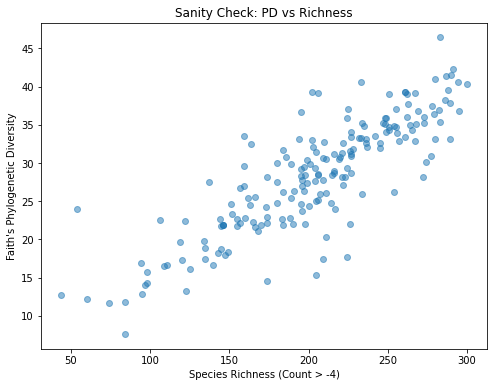

In [23]:
# Sanity check
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Calculate Simple Richness (Count of species > -4 log abundance)
# We drop the metadata columns first to ensure we only count bacteria

# 2. Plot
plt.figure(figsize=(8, 6))
plt.scatter(intervention_mb['Richness'], intervention_mb['Faith_index'], alpha=0.5)
plt.xlabel('Species Richness (Count > -4)')
plt.ylabel("Faith's Phylogenetic Diversity")
plt.title('Sanity Check: PD vs Richness')

# 3. Correlation Score
# corr, p_val = stats.spearmanr(gut_bacteria_df['Richness'], gut_bacteria_df['Faith_index'])
# print(f"Spearman Correlation: {corr:.2f} (Should be > 0.8)")
corr, p_val = stats.pearsonr(intervention_mb['Richness'], intervention_mb['Faith_index'])
print(f"Pearson Correlation: {corr:.2f} (Should be > 0.8)")
corr, p_val = stats.pearsonr(intervention_mb['Shannon_diversity'], intervention_mb['Faith_index'])
print(f"Pearson Correlation: {corr:.2f} (Should be > 0.8)")
corr, p_val = stats.pearsonr(intervention_mb['Richness'], intervention_mb['Shannon_diversity'])
print(f"Pearson Correlation: {corr:.2f} (Should be > 0.8)")
plt.show()

In [24]:
diversity_targets = ['Richness', 'Shannon_diversity', 'Faith_index']

## Load Diet Data

In [25]:
# Configure data directory based on study_id
study_id_value = study_ids[0]
if study_id_value == 'PNP3':
    nastya_dir = '/net/mraid20/export/genie/LabData/Data/StudySpecificData/PNP3/data/'
    file_suffix = 'pnp3'
elif study_id_value == 15:
    nastya_dir = '/net/mraid20/export/genie/LabData/Data/StudySpecificData/AU15/data/'  # Update this path if different
    file_suffix = 'au15'
else:
    nastya_dir = f'/net/mraid20/export/genie/LabData/Data/StudySpecificData/{study_name}/data/'
    file_suffix = study_name.lower()

baseline_nutrients = pd.read_csv(nastya_dir + f'baseline_log_{file_suffix}.csv')
intervention_nutrients = pd.read_csv(nastya_dir + f'intervention_log_{file_suffix}.csv')
# baseline_mb = pd.read_csv(nastya_dir + 'baseline_species.csv')
food_cat_baseline = pd.read_csv(nastya_dir + 'food_categories_bl.csv')
food_cat_diff = pd.read_csv(nastya_dir + 'food_categories_diff.csv')
food_cat_int = pd.read_csv(nastya_dir + 'food_categories_int.csv')
log_grouped_diff = pd.read_csv(nastya_dir + 'log_grouped_diff.csv')
species_change_all = pd.read_csv(nastya_dir + 'species_change_all.csv')
species_change_final = pd.read_csv(nastya_dir + 'species_changes_final.csv')
intervention_foods = pd.read_csv(nastya_dir + f'intervention_foods_{file_suffix}.csv')
intervention_foods_all = pd.read_csv(nastya_dir + f'intervention_foods_{file_suffix}_all.csv')
intervention_foods_all_full = pd.read_csv(nastya_dir + f'intervention_foods_{file_suffix}_all_full.csv')
baseline_foods_all = pd.read_csv(nastya_dir + f'baseline_foods_{file_suffix}_all.csv')



In [26]:
intervention_foods_all

,RegistrationCode,Acai,Actimel,Agave Syrup,Alaska pollock,Alfajores,Alfalfa sprouts,Alfredo Sauce,Almond Beverage,Almond Cake,...,Zucchini Fritters,Zucchini Patties,black pepper,dried tomato spread,emmer wheat bread,garlic paste,ginger,kale,pumpkin soup,sucra light
0,111527,NaN,NaN,NaN,NaN,NaN,2.32,122.53980,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.04656
1,117111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,126092,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,224.48,NaN,NaN,2.8,NaN,NaN
3,12752,NaN,NaN,NaN,NaN,NaN,2.32,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,775.92,NaN,NaN,NaN,NaN,NaN
4,130279,NaN,NaN,NaN,NaN,NaN,NaN,8.16932,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,981727,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,258.0,NaN,NaN,4733.60,NaN,NaN,NaN,NaN,NaN
221,988899,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
222,992638,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
223,997427,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,231.80,NaN,NaN,NaN,NaN,NaN


In [27]:
baseline_foods_all.columns

Index(['RegistrationCode', 'Acai', 'Actimel', 'Agave Syrup', 'Alaska pollock',
       'Alfajores', 'Alfalfa sprouts', 'Alfredo Sauce', 'Almond Beverage',
       'Almond Cake',
       ...
       'Zucchini Fritters', 'Zucchini Patties', 'black pepper',
       'dried tomato spread', 'emmer wheat bread', 'garlic paste', 'ginger',
       'kale', 'pumpkin soup', 'sucra light'],
      dtype='object', length=1429)

In [28]:
with open('/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/data/food_shortnames.pkl', 'rb') as file:
    food_shortnames = pickle.load(file)
food_shortnames

Index(['Acorn squash', 'Alfalfa sprouts', 'Almond Beverage', 'Almond flour',
       'Almond spread', 'Almonds', 'Amba', 'Apple', 'Apple Cake',
       'Apple Vinegar',
       ...
       'Yellow pepper', 'Yogurt', 'Zaatar', 'Zucchini', 'Zucchini Patties',
       'black pepper', 'dried tomato spread', 'emmer wheat bread', 'ginger',
       'kale'],
      dtype='object', name='shortname_eng', length=570)

In [29]:
baseline_foods_all

,RegistrationCode,Acai,Actimel,Agave Syrup,Alaska pollock,Alfajores,Alfalfa sprouts,Alfredo Sauce,Almond Beverage,Almond Cake,...,Zucchini Fritters,Zucchini Patties,black pepper,dried tomato spread,emmer wheat bread,garlic paste,ginger,kale,pumpkin soup,sucra light
0,111527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.01552
1,117111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,126092,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,12752,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,130279,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,981727,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3.84,NaN,NaN,NaN
221,988899,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
222,992638,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
223,997427,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
baseline_foods_all = baseline_foods_all.set_index('RegistrationCode')
baseline_foods = baseline_foods_all[[col for col in all_features_10k if col in baseline_foods_all.columns]]

intervention_foods_all = intervention_foods_all.set_index('RegistrationCode')
intervention_foods = intervention_foods_all[[col for col in all_features_10k if col in intervention_foods_all.columns]]

In [31]:
# Normalize by person to get mean % of daily calories
baseline_foods = baseline_foods.fillna(0)
baseline_foods = baseline_foods.div(baseline_foods.sum(axis=1), axis=0)
baseline_foods

intervention_foods = intervention_foods.fillna(0)
intervention_foods = intervention_foods.div(intervention_foods.sum(axis=1), axis=0)
intervention_foods

,Alfalfa sprouts,Almond Beverage,Almond spread,Almonds,Amba,Apple,Apple Cake,Apple juice,Apricot,Apropo,...,Yogurt,Zucchini,Zucchini Patties,black pepper,dried tomato spread,emmer wheat bread,ginger,kale,Water,Fructose
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
111527,0.000010,0.0,0.0,0.026425,0.000000,0.000000,0.0,0.000000,0.000000,0.0,...,0.000478,0.000473,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
117111,0.000000,0.0,0.0,0.000000,0.000000,0.014033,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
126092,0.000000,0.0,0.0,0.039094,0.000000,0.000024,0.0,0.000000,0.000051,0.0,...,0.000000,0.000015,0.000000,0.0,0.0,0.001029,0.0,0.000013,0.0,0.0
12752,0.000008,0.0,0.0,0.034366,0.000000,0.005692,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.002679,0.0,0.000000,0.0,0.0
130279,0.000000,0.0,0.0,0.012986,0.000000,0.011444,0.0,0.000000,0.000000,0.0,...,0.000000,0.000055,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
981727,0.000000,0.0,0.0,0.008323,0.000440,0.004238,0.0,0.002167,0.000000,0.0,...,0.000000,0.000000,0.001403,0.0,0.0,0.025742,0.0,0.000000,0.0,0.0
988899,0.000000,0.0,0.0,0.024194,0.000221,0.011293,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
992638,0.000000,0.0,0.0,0.000791,0.000000,0.006899,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0


In [32]:
# intervention_nutrients = intervention_nutrients.set_index('RegistrationCode').drop(['Main score'], axis=1)
# intervention_nutrients

In [33]:
# # Dictionary with the mappings for renaming
# rename_dict = {
#     'Fructose': 'Fructose',
#     'caffeine_mg': 'Caffeine',
#     'calcium_mg': 'Calcium, Ca',
#     'carbohydrate_g': 'Carbohydrate, by difference',
#     'cholesterol_mg': 'Cholesterol',
#     'iron_mg': 'Iron, Fe',
#     'magnesium_mg': 'Magnesium, Mg',
#     'niacin_mg': 'Niacin',
#     'phosphorus_mg': 'Phosphorus, P',
#     'potassium_mg': 'Potassium, K',
#     'protein_g': 'Protein',
#     'raevitamina_ug': 'Vitamin A, RAE',
#     'riboflavin_mg': 'Riboflavin',
#     'sodium_mg': 'Sodium, Na',
#     'thiamin_mg': 'Thiamin',
#     'totaldietaryfiber_g': 'Fiber, total dietary',
#     'totalfolate_ug': 'Folate, total',
#     'totallipid_g': 'Total lipid (fat)',
#     'totalmonounsaturatedfattyacids_g': 'Fatty acids, total monounsaturated',
#     'totalpolyunsaturatedfattyacids_g': 'Fatty acids, total polyunsaturated',
#     'totalsaturatedfattyacids_g': 'Fatty acids, total saturated',
#     'vitaminb12_ug': 'Vitamin B-12',
#     'vitaminb6_mg': 'Vitamin B-6',
#     'vitaminc_mg': 'Vitamin C, total ascorbic acid',
#     'vitamind_iu': 'Vitamin D (D2 + D3)',
#     'vitamine_mg': 'vitamin_E',
#     'zinc_mg': 'Zinc, Zn'
# }

# # Rename the items in the list using the mapping
# intervention_nutrients.columns = [rename_dict.get(item, item) for item in intervention_nutrients.columns]

# intervention_nutrients


In [34]:
# food_cat_baseline = food_cat_baseline.set_index('RegistrationCode')
# # Normalize by person to get mean % of daily calories
# food_cat_baseline = food_cat_baseline.div(food_cat_baseline.sum(axis=1), axis=0)
# food_cat_baseline

### BMI

In [35]:
bml = BodyMeasuresLoader()
# bmld = bml.get_data(study_ids=study_ids, cols=['weight', 'height', 'bmr'])
bmld = bml.get_data(study_ids=study_ids)
bmldf = bmld.df
bmldf.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 2146 entries, ('111527', Timestamp('2017-11-05 08:26:36')) to ('997735', Timestamp('2020-01-23 11:11:58'))
Data columns (total 35 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   neck_circumference                            0 non-null      float64
 1   standing_one_min_blood_pressure_systolic      0 non-null      float64
 2   standing_three_min_blood_pressure_diastolic   0 non-null      float64
 3   sitting_blood_pressure_diastolic              1062 non-null   float64
 4   sitting_blood_pressure_systolic               1062 non-null   float64
 5   standing_one_min_blood_pressure_pulse_rate    0 non-null      float64
 6   sitting_blood_pressure_pulse_rate             1056 non-null   float64
 7   body_temperature                              0 non-null      float64
 8   trunk_fat                                     1985 non-

In [36]:
bmldf

neck_circumference  \
RegistrationCode Date                                      
111527           2017-11-05 08:26:36                 NaN   
                 2017-12-05 12:34:48                 NaN   
                 2018-01-04 13:15:44                 NaN   
                 2018-02-07 10:33:23                 NaN   
                 2018-03-15 13:07:08                 NaN   
...                                                  ...   
997735           2019-05-28 10:29:47                 NaN   
                 2019-06-25 11:05:07                 NaN   
                 2019-07-25 08:50:08                 NaN   
                 2019-10-23 11:03:51                 NaN   
                 2020-01-23 11:11:58                 NaN   

                                      standing_one_min_blood_pressure_systolic  \
RegistrationCode Date                                                            
111527           2017-11-05 08:26:36                                       NaN   
                 2017-12-05 12:34:48                                       NaN   
                 2018-01-04 13:15:44                                       NaN   
                 2018-02-07 10:33:23                                       NaN   
                 2018-03-15 13:07:08                                       NaN   
...                                                                        ...   
997735           2019-05-28 10:29:47                                       NaN   
                 2019-06-25 11:05:07                                       NaN   
                 2019-07-25 08:50:08                                       NaN   
                 2019-10-23 11:03:51                                       NaN   
                 2020-01-23 11:11:58                                       NaN   

                                      standing_three_min_blood_pressure_diastolic  \
RegistrationCode Date                                                               
111527           2017-11-05 08:26:36                                          NaN   
                 2017-12-05 12:34:48                                          NaN   
                 2018-01-04 13:15:44                                          NaN   
                 2018-02-07 10:33:23                                          NaN   
                 2018-03-15 13:07:08                                          NaN   
...                                                                           ...   
997735           2019-05-28 10:29:47                                          NaN   
                 2019-06-25 11:05:07                                          NaN   
                 2019-07-25 08:50:08                                          NaN   
                 2019-10-23 11:03:51                                          NaN   
                 2020-01-23 11:11:58                                          NaN   

                                      sitting_blood_pressure_diastolic  \
RegistrationCode Date                                                    
111527           2017-11-05 08:26:36                              89.0   
                 2017-12-05 12:34:48                              88.0   
                 2018-01-04 13:15:44                               NaN   
                 2018-02-07 10:33:23                               NaN   
                 2018-03-15 13:07:08                              93.0   
...                                                                ...   
997735           2019-05-28 10:29:47                               NaN   
                 2019-06-25 11:05:07                               NaN   
                 2019-07-25 08:50:08                              80.0   
                 2019-10-23 11:03:51                               NaN   
                 2020-01-23 11:11:58                              78.0   

                                      sitting_blood_pressure_systolic  \
RegistrationCode Date                           

In [37]:
import pandas as pd
import numpy as np

# 1. Reset index to make columns accessible
#    This moves 'RegistrationCode' and 'Date' from the index into regular columns
df = bmldf.reset_index()

# 2. Ensure Date is in datetime format (handles strings automatically)
df['Date'] = pd.to_datetime(df['Date'])

# 3. Sort by Code and Date to ensure order is chronological
df = df.sort_values(by=['RegistrationCode', 'Date'])

# --- Create Baseline DataFrame ---
# Group by ID and take the first (earliest) row
bmldf_baseline = df.groupby('RegistrationCode').first().reset_index()


# --- Create Intervention DataFrame ---

# A. Merge the baseline date back into the main dataframe for comparison
#    We create a temporary dataframe with just the ID and the Baseline Date
baseline_dates = bmldf_baseline[['RegistrationCode', 'Date']].rename(
    columns={'Date': 'baseline_date'}
)
df_merged = pd.merge(df, baseline_dates, on='RegistrationCode', how='inner')

# B. Calculate the difference in months
#    We calculate the difference in nanoseconds and divide by the average duration of a month
df_merged['months_diff'] = (df_merged['Date'] - df_merged['baseline_date']) / np.timedelta64(1, 'M')

# C. Filter: Keep rows strictly between 5 and 7 months after baseline
#    (You can adjust the boundaries or use >= if you want inclusive)
mask = (df_merged['months_diff'] >= 5) & (df_merged['months_diff'] <= 7)
df_intervention_candidates = df_merged[mask]

# D. Select the LATEST row from the candidates
#    (The user requested the "latest row" within that window)
bmldf_intervention = df_intervention_candidates.sort_values('Date').groupby('RegistrationCode').last().reset_index()


# --- Cleanup ---

# 4. Restore the original MultiIndex for both result dataframes
#    We drop the helper columns we created
bmldf_baseline = bmldf_baseline.set_index(['RegistrationCode', 'Date'])

# For intervention, we also need to drop the helper calculation columns
cols_to_drop = ['baseline_date', 'months_diff']
bmldf_intervention = bmldf_intervention.drop(columns=cols_to_drop).set_index(['RegistrationCode', 'Date'])

# Verify results
print(f"Baseline shape: {bmldf_baseline.shape}")
print(f"Intervention shape: {bmldf_intervention.shape}")

Baseline shape: (248, 35)
Intervention shape: (199, 35)


In [38]:
bmldf_baseline["bmi"]

RegistrationCode  Date               
111527            2017-11-05 08:26:36    30.990305
117111            2018-04-23 13:30:30    34.780960
126092            2018-11-11 09:00:30    24.335938
12752             2018-11-11 09:00:30    27.853241
128811            2017-11-06 08:32:14    27.552959
                                           ...    
988899            2017-09-24 09:58:17    41.016312
991569            2017-11-05 08:26:36    35.685787
992638            2017-06-13 12:08:34    27.281746
997427            2019-02-03 12:10:36    34.744881
997735            2018-12-23 14:11:30    36.616344
Name: bmi, Length: 248, dtype: float64

In [39]:
bmldf_intervention["bmi"]

RegistrationCode  Date               
111527            2018-05-16 13:48:26    30.730610
117111            2018-09-26 15:56:37    34.118168
126092            2019-05-21 11:02:22    22.773438
12752             2019-05-21 11:02:22    26.909548
130279            2019-03-07 11:02:56    30.011612
                                           ...    
981727            2019-04-28 13:58:52    26.229223
988899            2018-03-25 10:31:37    41.935692
992638            2018-01-07 12:47:37    26.537699
997427            2019-08-08 14:10:52    34.816593
997735            2019-06-25 11:05:07    35.164757
Name: bmi, Length: 199, dtype: float64

## Combine Dataframes

In [40]:
# baseline_nutrients = baseline_nutrients.set_index('RegistrationCode')
# baseline_nutrients.columns = [rename_dict.get(item, item) for item in baseline_nutrients.columns]
# baseline_nutrients

In [41]:
# diet_mb = baseline_foods.join(baseline_nutrients, how='inner')
# # diet_mb = diet_mb.dropna()
# diet_mb

# diet_mb_intervention = intervention_foods.join(intervention_nutrients, how='inner')
# diet_mb_intervention

In [42]:
subjects_df = subjects_df.reset_index(level=[1], drop=True)

In [43]:
subjects_df

,StudyTypeID,city,country,gender,month_of_birth,us_state,yob,StudyTypeID2,StudyTypeID3,StudyTypeID4,StudyTypeID5,StudyTypeID6,StudyTypeID7,StudyTypeID8,StudyTypeID9,age,tz
RegistrationCode,,,,,,,,,,,,,,,,,
111527,3.0,None,IL,0.0,None,None,1971.0,NaN,None,None,None,None,None,None,None,46.0,Asia/Jerusalem
117111,3.0,None,IL,1.0,None,None,1971.0,NaN,None,None,None,None,None,None,None,47.0,Asia/Jerusalem
126092,3.0,None,IL,0.0,None,None,1962.0,NaN,None,None,None,None,None,None,None,56.0,Asia/Jerusalem
12752,3.0,None,IL,1.0,None,None,1962.0,NaN,None,None,None,None,None,None,None,56.0,Asia/Jerusalem
128811,3.0,None,IL,1.0,None,None,1971.0,NaN,None,None,None,None,None,None,None,46.0,Asia/Jerusalem
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
988899,3.0,None,IL,1.0,None,None,1981.0,NaN,None,None,None,None,None,None,None,36.0,Asia/Jerusalem
991569,3.0,None,IL,1.0,None,None,1966.0,NaN,None,None,None,None,None,None,None,51.0,Asia/Jerusalem
992638,3.0,None,IL,1.0,None,None,1964.0,NaN,None,None,None,None,None,None,None,53.0,Asia/Jerusalem


In [44]:
base_features = ["age", "gender"]
subjects_df.index = subjects_df.index.astype('int')
baseline_foods = baseline_foods.join(subjects_df[base_features])
baseline_foods = baseline_foods.rename(columns={'gender': 'sex'})
# diet_mb = diet_mb.reset_index(level=[1], drop=True)
# diet_mb = diet_mb.dropna()
baseline_foods


intervention_foods = intervention_foods.join(subjects_df[base_features])
intervention_foods = intervention_foods.rename(columns={'gender': 'sex'})
# diet_mb = diet_mb.reset_index(level=[1], drop=True)
# diet_mb = diet_mb.dropna()
intervention_foods

,Alfalfa sprouts,Almond Beverage,Almond spread,Almonds,Amba,Apple,Apple Cake,Apple juice,Apricot,Apropo,...,Zucchini Patties,black pepper,dried tomato spread,emmer wheat bread,ginger,kale,Water,Fructose,age,sex
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
111527,0.000010,0.0,0.0,0.026425,0.000000,0.000000,0.0,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,46.0,0.0
117111,0.000000,0.0,0.0,0.000000,0.000000,0.014033,0.0,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,47.0,1.0
126092,0.000000,0.0,0.0,0.039094,0.000000,0.000024,0.0,0.000000,0.000051,0.0,...,0.000000,0.0,0.0,0.001029,0.0,0.000013,0.0,0.0,56.0,0.0
12752,0.000008,0.0,0.0,0.034366,0.000000,0.005692,0.0,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.002679,0.0,0.000000,0.0,0.0,56.0,1.0
130279,0.000000,0.0,0.0,0.012986,0.000000,0.011444,0.0,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,56.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
981727,0.000000,0.0,0.0,0.008323,0.000440,0.004238,0.0,0.002167,0.000000,0.0,...,0.001403,0.0,0.0,0.025742,0.0,0.000000,0.0,0.0,61.0,1.0
988899,0.000000,0.0,0.0,0.024194,0.000221,0.011293,0.0,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,36.0,1.0
992638,0.000000,0.0,0.0,0.000791,0.000000,0.006899,0.0,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,53.0,1.0


In [45]:

# Drop the second level of index for bmldf_baseline and bmldf_intervention (leaving only RegistrationCode)
bmldf_baseline = bmldf_baseline.reset_index(level=1, drop=True)
bmldf_baseline.index = bmldf_baseline.index.astype('int')
baseline_foods = baseline_foods.join(bmldf_baseline["bmi"])
baseline_foods

bmldf_intervention = bmldf_intervention.reset_index(level=1, drop=True)
bmldf_intervention.index = bmldf_intervention.index.astype('int')
intervention_foods = intervention_foods.join(bmldf_intervention["bmi"])
intervention_foods


,Alfalfa sprouts,Almond Beverage,Almond spread,Almonds,Amba,Apple,Apple Cake,Apple juice,Apricot,Apropo,...,black pepper,dried tomato spread,emmer wheat bread,ginger,kale,Water,Fructose,age,sex,bmi
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
111527,0.000010,0.0,0.0,0.026425,0.000000,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,46.0,0.0,30.730610
117111,0.000000,0.0,0.0,0.000000,0.000000,0.014033,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,47.0,1.0,34.118168
126092,0.000000,0.0,0.0,0.039094,0.000000,0.000024,0.0,0.000000,0.000051,0.0,...,0.0,0.0,0.001029,0.0,0.000013,0.0,0.0,56.0,0.0,22.773438
12752,0.000008,0.0,0.0,0.034366,0.000000,0.005692,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.002679,0.0,0.000000,0.0,0.0,56.0,1.0,26.909548
130279,0.000000,0.0,0.0,0.012986,0.000000,0.011444,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,56.0,1.0,30.011612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
981727,0.000000,0.0,0.0,0.008323,0.000440,0.004238,0.0,0.002167,0.000000,0.0,...,0.0,0.0,0.025742,0.0,0.000000,0.0,0.0,61.0,1.0,26.229223
988899,0.000000,0.0,0.0,0.024194,0.000221,0.011293,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,36.0,1.0,41.935692
992638,0.000000,0.0,0.0,0.000791,0.000000,0.006899,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,53.0,1.0,26.537699


In [46]:
pnp3_diet_features = baseline_foods.columns
pnp3_diet_features

Index(['Alfalfa sprouts', 'Almond Beverage', 'Almond spread', 'Almonds',
       'Amba', 'Apple', 'Apple Cake', 'Apple juice', 'Apricot', 'Apropo',
       ...
       'black pepper', 'dried tomato spread', 'emmer wheat bread', 'ginger',
       'kale', 'Water', 'Fructose', 'age', 'sex', 'bmi'],
      dtype='object', length=527)

In [47]:
pnp3_10k_shared_features = [col for col in pnp3_diet_features if col in all_features_10k]
pnp3_10k_shared_features.remove('Fructose')
pnp3_10k_shared_features

['Alfalfa sprouts',
 'Almond Beverage',
 'Almond spread',
 'Almonds',
 'Amba',
 'Apple',
 'Apple Cake',
 'Apple juice',
 'Apricot',
 'Apropo',
 'Artichoke',
 'Arugula',
 'Asparagus',
 'Avocado',
 'Avocado Sandwich',
 'Bagel',
 'Baguette',
 'Baked apple',
 'Baklava',
 'Balsamic vinegar',
 'Bamba',
 'Banana',
 'Banana Cake',
 'Barbecue sauce',
 'Barley soup',
 'Basil',
 'Bean soup',
 'Beans black-eyed peas',
 'Beef',
 'Beef Cholent',
 'Beef Lasagna',
 'Beef Shawarma',
 'Beer',
 'Beet',
 'Beet Salad',
 'Biscuit',
 'Bissli',
 'Black beans',
 'Blintzes',
 'Blueberries',
 'Boiled corn',
 'Bolognese',
 'Brazil nuts',
 'Bread',
 'Bread Crumbs',
 'Broccoli',
 'Broth',
 'Brown Rice',
 'Brown Sugar',
 'Brownies',
 'Buckwheat crackers',
 'Bulgur',
 'Burekas',
 'Butter',
 'Butter Cookies',
 'Caesar Salad',
 'Cake',
 'Calamari',
 'Camembert or Brie',
 'Candies',
 'Canned Sardine',
 'Canned Tuna Fish',
 'Canned corn',
 'Cappuccino',
 'Carrot Cake',
 'Carrot Juice',
 'Carrot Salad',
 'Carrots',
 'Cash

In [48]:
len(pnp3_10k_shared_features)

526

In [49]:
baseline_foods = baseline_foods[pnp3_10k_shared_features]
intervention_foods = intervention_foods[pnp3_10k_shared_features]

In [50]:
baseline_mb.index = baseline_mb.index.astype('int')
diet_mb_baseline = baseline_foods.join(baseline_mb)
diet_mb_baseline

,Alfalfa sprouts,Almond Beverage,Almond spread,Almonds,Amba,Apple,Apple Cake,Apple juice,Apricot,Apropo,...,fBin__94|gBin__448|sBin__654,fBin__94|gBin__449|sBin__656,fBin__95|gBin__450|sBin__659,fBin__96|gBin__457|sBin__669,fBin__97|gBin__462|sBin__676,fBin__97|gBin__462|sBin__678,fBin__99|gBin__469|sBin__687,Richness,Shannon_diversity,Faith_index
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
111527,0.0,0.0,0.0,0.013741,0.000000,0.000000,0.000000,0.0,0.000000,0.0,...,-4.000000,-4.0,-4.000000,-2.316650,-4.0,-4.000000,-4.000000,110.0,2.69,18.406913
117111,0.0,0.0,0.0,0.000000,0.000000,0.014040,0.000000,0.0,0.000000,0.0,...,-4.000000,-4.0,-2.772134,-4.000000,-4.0,-4.000000,-4.000000,163.0,3.33,23.952442
126092,0.0,0.0,0.0,0.004597,0.000000,0.004053,0.000000,0.0,0.000000,0.0,...,-4.000000,-4.0,-4.000000,-3.098488,-4.0,-4.000000,-2.382134,184.0,3.32,27.321507
12752,0.0,0.0,0.0,0.005557,0.000000,0.007999,0.000000,0.0,0.000000,0.0,...,-3.635983,-4.0,-4.000000,-4.000000,-4.0,-4.000000,-2.999455,107.0,2.20,17.454794
130279,0.0,0.0,0.0,0.003899,0.000000,0.020388,0.000000,0.0,0.000000,0.0,...,-4.000000,-4.0,-4.000000,-4.000000,-4.0,-4.000000,-4.000000,159.0,1.73,21.982700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
981727,0.0,0.0,0.0,0.000000,0.000000,0.003048,0.021718,0.0,0.000000,0.0,...,-3.071785,-4.0,-2.884203,-4.000000,-4.0,-4.000000,-4.000000,260.0,4.07,37.690415
988899,0.0,0.0,0.0,0.000000,0.000518,0.001211,0.000000,0.0,0.000000,0.0,...,-3.090213,-4.0,-4.000000,-4.000000,-4.0,-4.000000,-4.000000,146.0,2.38,21.958867
992638,0.0,0.0,0.0,0.000000,0.000000,0.004343,0.000000,0.0,0.000627,0.0,...,-3.560856,-4.0,-4.000000,-4.000000,-4.0,-3.780138,-4.000000,167.0,2.50,21.776495


In [51]:
intervention_mb.index = intervention_mb.index.astype('int')
diet_mb_intervention = intervention_foods.join(intervention_mb)
diet_mb_intervention

,Alfalfa sprouts,Almond Beverage,Almond spread,Almonds,Amba,Apple,Apple Cake,Apple juice,Apricot,Apropo,...,fBin__94|gBin__448|sBin__654,fBin__94|gBin__449|sBin__656,fBin__95|gBin__450|sBin__659,fBin__96|gBin__457|sBin__669,fBin__97|gBin__462|sBin__676,fBin__97|gBin__462|sBin__678,fBin__99|gBin__469|sBin__687,Richness,Shannon_diversity,Faith_index
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
111527,0.000010,0.0,0.0,0.026425,0.000000,0.000000,0.0,0.000000,0.000000,0.0,...,-4.000000,-4.000000,-4.000000,-2.508685,-4.0,-4.000000,-4.000000,149.0,3.46,18.406913
117111,0.000000,0.0,0.0,0.000000,0.000000,0.014033,0.0,0.000000,0.000000,0.0,...,-4.000000,-3.327926,-2.345744,-4.000000,-4.0,-4.000000,-4.000000,217.0,3.93,23.952442
126092,0.000000,0.0,0.0,0.039094,0.000000,0.000024,0.0,0.000000,0.000051,0.0,...,-4.000000,-4.000000,-4.000000,-2.595642,-4.0,-4.000000,-2.013733,199.0,3.94,27.321507
12752,0.000008,0.0,0.0,0.034366,0.000000,0.005692,0.0,0.000000,0.000000,0.0,...,-3.140830,-4.000000,-4.000000,-4.000000,-4.0,-4.000000,-2.458283,209.0,3.97,17.454794
130279,0.000000,0.0,0.0,0.012986,0.000000,0.011444,0.0,0.000000,0.000000,0.0,...,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-3.760075,-4.000000,198.0,2.62,21.982700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
981727,0.000000,0.0,0.0,0.008323,0.000440,0.004238,0.0,0.002167,0.000000,0.0,...,-2.852334,-4.000000,-2.330696,-4.000000,-4.0,-4.000000,-4.000000,263.0,3.97,37.690415
988899,0.000000,0.0,0.0,0.024194,0.000221,0.011293,0.0,0.000000,0.000000,0.0,...,-3.575834,-4.000000,-4.000000,-4.000000,-4.0,-4.000000,-4.000000,190.0,2.10,21.958867
992638,0.000000,0.0,0.0,0.000791,0.000000,0.006899,0.0,0.000000,0.000000,0.0,...,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.000000,-4.000000,145.0,2.22,21.776495


In [52]:
# from sklearn.preprocessing import StandardScaler

# with open(home_path + f'data/{SPECIES}/age_scaler.pkl', 'rb') as f:
#     age_scaler = pickle.load(f)

# with open(home_path + f'data/{SPECIES}/mb_scaler.pkl', 'rb') as f:
#     mb_scaler = pickle.load(f)

# with open(home_path + f'data/{SPECIES}/div_scaler.pkl', 'rb') as f:
#     div_scaler = pickle.load(f)

# diet_scaler = StandardScaler()
# diet_mb_10k_scaled = diet_scaler.fit_transform(diet_mb_10k[pnp3_10k_shared_features])

# # # Apply the scaler to the dataframe
# diet_mb_baseline.loc[:, pnp3_10k_shared_features] = diet_scaler.transform(diet_mb_baseline[pnp3_10k_shared_features])
# diet_mb_baseline.loc[:, ["age"]] = age_scaler.transform(diet_mb_baseline[["age"]])
# diet_mb_baseline.loc[:, targets_10k] = mb_scaler.transform(diet_mb_baseline[targets_10k])
# diet_mb_baseline.loc[:, ["Richness", "Shannon_diversity"]] = div_scaler.transform(diet_mb_baseline[["Richness", "Shannon_diversity"]])
# # diet_mb_baseline[pnp3_10k_shared_features] = pd.DataFrame(scaler.transform(diet_mb_baseline[pnp3_10k_shared_features]), columns=diet_mb_baseline[pnp3_10k_shared_features].columns, index=diet_mb_baseline[pnp3_10k_shared_features].index)
# diet_mb_baseline.describe()

In [53]:
# # # Apply the scaler to the dataframe
# diet_mb_intervention.loc[:, pnp3_10k_shared_features] = diet_scaler.transform(diet_mb_intervention[pnp3_10k_shared_features])
# diet_mb_intervention.loc[:, ["age"]] = age_scaler.transform(diet_mb_intervention[["age"]])
# diet_mb_intervention.loc[:, targets_10k] = mb_scaler.transform(diet_mb_intervention[targets_10k])
# diet_mb_intervention.loc[:, ["Richness", "Shannon_diversity"]] = div_scaler.transform(diet_mb_intervention[["Richness", "Shannon_diversity"]])
# diet_mb_intervention.describe()

In [54]:
# Count rows that have at least one NaN
nan_rows = diet_mb_intervention[diet_mb_intervention.isna().any(axis=1)]
num_nan_rows = len(nan_rows)

# Find which columns contain NaN values
nan_features = diet_mb_intervention.columns[diet_mb_intervention.isna().any()].tolist()

print(f"Number of rows with at least one NaN: {num_nan_rows}")
print("Features that contain NaN values:")
print(nan_features)


Number of rows with at least one NaN: 40
Features that contain NaN values:
['age', 'sex', 'bmi', 'fBin__100|gBin__473|sBin__693', 'fBin__100|gBin__473|sBin__694', 'fBin__100|gBin__474|sBin__695', 'fBin__100|gBin__477|sBin__698', 'fBin__100|gBin__481|sBin__704', 'fBin__100|gBin__481|sBin__705', 'fBin__100|gBin__481|sBin__706', 'fBin__100|gBin__483|sBin__709', 'fBin__102|gBin__490|sBin__720', 'fBin__102|gBin__490|sBin__721', 'fBin__102|gBin__490|sBin__722', 'fBin__103|gBin__491|sBin__727', 'fBin__104|gBin__493|sBin__730', 'fBin__104|gBin__494|sBin__731', 'fBin__104|gBin__495|sBin__732', 'fBin__104|gBin__496|sBin__733', 'fBin__104|gBin__496|sBin__734', 'fBin__104|gBin__498|sBin__736', 'fBin__104|gBin__500|sBin__738', 'fBin__108|gBin__515|sBin__766', 'fBin__108|gBin__515|sBin__767', 'fBin__108|gBin__517|sBin__769', 'fBin__108|gBin__521|sBin__773', 'fBin__108|gBin__523|sBin__776', 'fBin__108|gBin__525|sBin__778', 'fBin__108|gBin__526|sBin__779', 'fBin__108|gBin__531|sBin__787', 'fBin__121|g

In [55]:
print("\nNaN count per column:")
print(diet_mb_intervention.isna().sum()[diet_mb_intervention.isna().sum() > 0])
diet_mb_baseline = diet_mb_baseline.dropna(how='any')
diet_mb_intervention = diet_mb_intervention.dropna(how='any')



NaN count per column:
age                               2
sex                               2
bmi                              28
fBin__100|gBin__473|sBin__693    36
fBin__100|gBin__473|sBin__694    36
                                 ..
fBin__97|gBin__462|sBin__678     36
fBin__99|gBin__469|sBin__687     36
Richness                         36
Shannon_diversity                36
Faith_index                      36
Length: 730, dtype: int64


In [56]:
# Making sure we have the exact same patients in each data
common_indices = diet_mb_baseline.index.intersection(diet_mb_intervention.index)
diet_mb_baseline = diet_mb_baseline.loc[common_indices].sort_index()
diet_mb_intervention = diet_mb_intervention.loc[common_indices].sort_index()
print(diet_mb_baseline.shape)
print(diet_mb_intervention.shape)

(185, 1253)
(185, 1253)


In [57]:
print(diet_mb_baseline.shape)
print(diet_mb_intervention.shape)

(185, 1253)
(185, 1253)


In [58]:
diet_mb_baseline.to_pickle(home_path + f'data/diet_mb_{study_name.lower()}_baseline.pkl')
with open(home_path + f'data/my_lists_{study_name.lower()}.pkl', 'wb') as file:
    pickle.dump([pnp3_10k_shared_features, targets_10k], file)
    
diet_mb_intervention.to_pickle(home_path + f'data/diet_mb_{study_name.lower()}_intervention.pkl')

In [59]:
print(len(pnp3_10k_shared_features))
print(len(targets_10k))

526
724
